# Elite Football Injury-Risk Prediction — 14-Day Horizon

**Business objective:** Improve player availability during UEFA-like competition windows by predicting time-loss injuries within the next 14 days.

**Preferred label scope:** Non-contact lower-limb soft-tissue injuries (hamstring, groin/adductor, calf).

**Data sources used:**
| Source | Role | Key fields |
|--------|------|------------|
| `transfermarkt-datasets/appearances.csv.gz` | Match exposure backbone | player_id, game_id, date, minutes_played |
| `transfermarkt-datasets/games.csv.gz` | Match metadata | game_id, competition_id, season, date |
| `transfermarkt-datasets/players.csv.gz` | Player demographics | player_id, position, date_of_birth, height |
| `transfermarkt/player_injuries/player_injuries.csv` | Injury label source | player_id, injury_reason, from_date, end_date, days_missed |

**Governance note:** Injury history, wellness, and model outputs are health-sensitive. Any production deployment must be human-supervised with explicit governance controls. This analysis is a research prototype only.

In [1]:
# ── Imports & configuration ──────────────────────────────────────────
import warnings, pathlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, accuracy_score,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
import lightgbm as lgb

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA = pathlib.Path("../data")
print("Setup complete.")

Setup complete.


---
# A. Statistical Description of the Data

We audit four source tables: **appearances**, **games**, **players**, and **injuries**. The goal is to quantify data volume, quality, joinability, and class balance — the evidence needed to justify modeling scope.

In [2]:
# ── A1. Load all source tables ───────────────────────────────────────
appearances = pd.read_csv(DATA / "transfermarkt-datasets/appearances.csv.gz")
games       = pd.read_csv(DATA / "transfermarkt-datasets/games.csv.gz")
players     = pd.read_csv(DATA / "transfermarkt-datasets/players.csv.gz")
injuries    = pd.read_csv(DATA / "transfermarkt/player_injuries/player_injuries.csv")

sources = {
    "appearances": appearances,
    "games": games,
    "players": players,
    "injuries": injuries,
}

# ── Quick audit per table ────────────────────────────────────────────
audit_rows = []
for name, df in sources.items():
    audit_rows.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_%": round(df.isna().mean().mean() * 100, 2),
    })

audit_df = pd.DataFrame(audit_rows)
print("=== Source Table Audit ===")
display(audit_df)

for name, df in sources.items():
    print(f"\n--- {name} columns ---")
    print(f"  dtypes: {dict(df.dtypes.value_counts())}")
    print(f"  columns: {df.columns.tolist()}")

=== Source Table Audit ===


,table,rows,columns,duplicate_rows,total_missing_%
0,appearances,1734466,13,0,0.00
1,games,79797,23,0,4.12
2,players,33789,23,0,5.98
3,injuries,143195,7,111,0.16



--- appearances columns ---
  dtypes: {dtype('int64'): np.int64(9), dtype('O'): np.int64(4)}
  columns: ['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']

--- games columns ---
  dtypes: {dtype('O'): np.int64(14), dtype('int64'): np.int64(6), dtype('float64'): np.int64(3)}
  columns: ['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away_club_position', 'home_club_manager_name', 'away_club_manager_name', 'stadium', 'attendance', 'referee', 'url', 'home_club_formation', 'away_club_formation', 'home_club_name', 'away_club_name', 'aggregate', 'competition_type']

--- players columns ---
  dtypes: {dtype('O'): np.int64(17), dtype('int64'): np.int64(3), dtype('float64'): np.int64(3)}
  columns: ['player_id', 'first_name', 'last_name', 'name', 'last_s

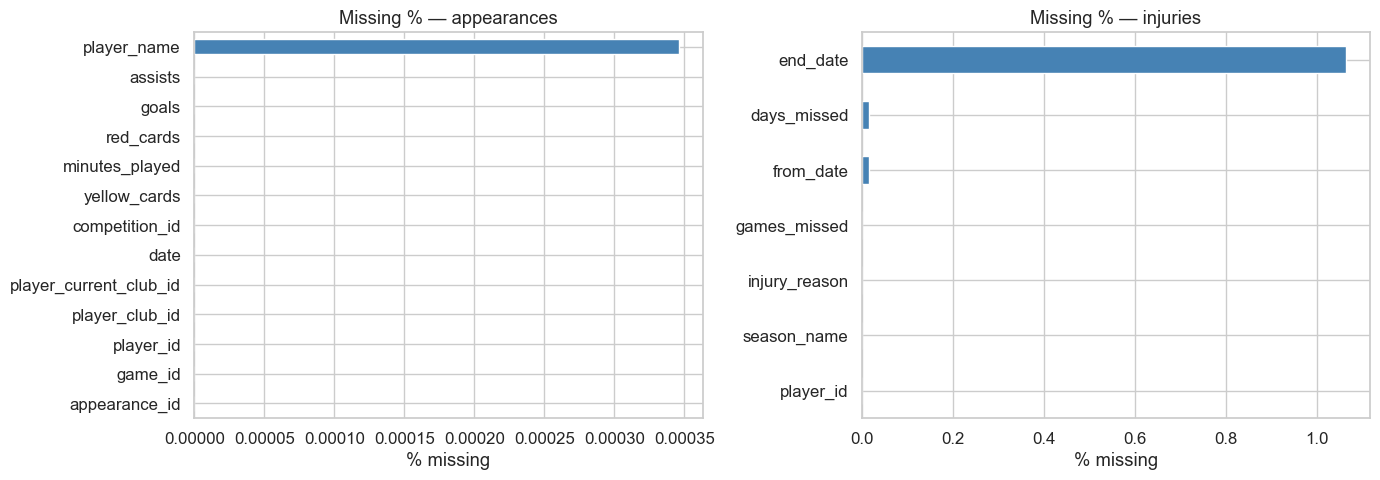

In [3]:
# ── A2. Missing values per column (key tables) ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [("appearances", appearances), ("injuries", injuries)]):
    miss = df.isna().mean().sort_values(ascending=True) * 100
    miss.plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"Missing % — {name}")
    ax.set_xlabel("% missing")

plt.tight_layout()
plt.show()

In [4]:
# ── A3. Injury data deep-dive ────────────────────────────────────────
print(f"Injury records:     {len(injuries):,}")
print(f"Unique players:     {injuries.player_id.nunique():,}")

# Peek at date range (parse temporarily)
_fd = pd.to_datetime(injuries.from_date, errors="coerce")
print(f"Date range:         {_fd.min()} → {_fd.max()}")
print(f"days_missed null:   {injuries.days_missed.isna().sum():,} ({injuries.days_missed.isna().mean()*100:.1f}%)")
print(f"games_missed null:  {injuries.games_missed.isna().sum():,} ({injuries.games_missed.isna().mean()*100:.1f}%)")

# Target-relevant injuries: non-contact lower-limb soft-tissue
target_keywords = [
    "hamstring", "groin", "adductor", "calf",
    "thigh", "muscle injury", "muscular problems",
    "muscle fatigue", "torn muscle fiber", "muscle",
]

def is_target_injury(reason):
    """Flag lower-limb soft-tissue injuries based on keyword matching."""
    if pd.isna(reason):
        return False
    reason_lower = reason.lower()
    return any(kw in reason_lower for kw in target_keywords)

injuries["is_target_injury"] = injuries["injury_reason"].apply(is_target_injury)

print(f"\n=== Target injury filter ===")
print(f"Target injuries (lower-limb soft-tissue): {injuries.is_target_injury.sum():,} "
      f"({injuries.is_target_injury.mean()*100:.1f}%)")
print(f"\nTop target injury reasons:")
display(injuries.loc[injuries.is_target_injury, "injury_reason"].value_counts().head(15))

Injury records:     143,195
Unique players:     34,561
Date range:         1973-09-02 00:00:00 → 2025-12-22 00:00:00
days_missed null:   22 (0.0%)
games_missed null:  0 (0.0%)

=== Target injury filter ===
Target injuries (lower-limb soft-tissue): 37,971 (26.5%)

Top target injury reasons:


injury_reason
Muscle injury              6433
Hamstring injury           5786
muscular problems          4880
Torn muscle fiber          2662
Thigh problems             2628
Calf injury                1884
Adductor pain              1559
Adductor injury            1374
Groin injury               1303
Hamstring strain           1280
Calf problems              1075
Muscle fatigue              829
Groin problems              759
Torn muscle bundle          746
Hamstring muscle injury     667
Name: count, dtype: int64

In [5]:
# ── A4. Appearances data deep-dive ───────────────────────────────────
print(f"Appearance records: {len(appearances):,}")
print(f"Unique players:     {appearances.player_id.nunique():,}")
print(f"Date range:         {appearances.date.min()} → {appearances.date.max()}")
print(f"minutes_played — min: {appearances.minutes_played.min()}, "
      f"max: {appearances.minutes_played.max()}, "
      f"mean: {appearances.minutes_played.mean():.1f}")

# Players overlapping between injuries and appearances
overlap_ids = set(appearances.player_id.unique()) & set(injuries.player_id.unique())
print(f"\nPlayers in BOTH appearances & injuries: {len(overlap_ids):,}")
print(f"  → appearances rows for these players: "
      f"{appearances[appearances.player_id.isin(overlap_ids)].shape[0]:,}")

# Competition distribution
print(f"\nTop 10 competitions by appearances:")
display(appearances.competition_id.value_counts().head(10))

Appearance records: 1,734,466
Unique players:     26,261


Date range:         2012-07-03 → 2025-07-13
minutes_played — min: 1, max: 148, mean: 68.9

Players in BOTH appearances & injuries: 15,670


  → appearances rows for these players: 1,418,820

Top 10 competitions by appearances:


competition_id
IT1    143261
ES1    141924
GB1    138259
FR1    134016
TR1    123030
L1     115061
NL1    110571
PO1    110443
BE1     93594
RU1     88075
Name: count, dtype: int64

In [6]:
# ── A5. Joinability summary ──────────────────────────────────────────
# Join logic:
#   appearances ──(player_id)──> injuries   (label generation)
#   appearances ──(game_id)───> games       (competition context)
#   appearances ──(player_id)──> players    (demographics)

join_checks = {
    "appearances ⟷ injuries (player_id)": len(overlap_ids),
    "appearances ⟷ games (game_id)": len(
        set(appearances.game_id.unique()) & set(games.game_id.unique())
    ),
    "appearances ⟷ players (player_id)": len(
        set(appearances.player_id.unique()) & set(players.player_id.unique())
    ),
}

print("=== Joinability (shared key count) ===")
for desc, n in join_checks.items():
    print(f"  {desc}: {n:,}")

print("\n=== Data sufficiency judgment ===")
print("  ✓ 15K+ players with both appearances and injury history")
print("  ✓ 1.7M+ appearance rows provide dense exposure signal")
print("  ✓ 30K+ target injuries for label construction")
print("  ✗ No GPS/tracking or wellness data → workload proxies only")
print("  ✗ Injury labels are crowd-sourced (Transfermarkt) → some noise expected")

=== Joinability (shared key count) ===
  appearances ⟷ injuries (player_id): 15,670
  appearances ⟷ games (game_id): 67,645
  appearances ⟷ players (player_id): 26,258

=== Data sufficiency judgment ===
  ✓ 15K+ players with both appearances and injury history
  ✓ 1.7M+ appearance rows provide dense exposure signal
  ✓ 30K+ target injuries for label construction
  ✗ No GPS/tracking or wellness data → workload proxies only
  ✗ Injury labels are crowd-sourced (Transfermarkt) → some noise expected


---
# B. Data Preparation

**Pipeline:**
1. Parse dates, filter to overlapping time window (2012–2025), restrict to players with injury data
2. Build the **14-day forward injury label**: for each appearance, does a target injury start within the next 14 days?
3. Engineer **rolling workload features** (7 / 14 / 28-day windows) and **injury history features**
4. Merge player demographics
5. Temporal train/test split (season-based)

**Leakage prevention:** All features are computed strictly from data *before* the appearance date. The label looks forward only.

In [7]:
# ── B1. Parse dates & filter ─────────────────────────────────────────
appearances["date"] = pd.to_datetime(appearances["date"])
injuries["from_date"] = pd.to_datetime(injuries["from_date"], errors="coerce")
injuries["end_date"] = pd.to_datetime(injuries["end_date"], errors="coerce")
games["date"] = pd.to_datetime(games["date"], errors="coerce")
players["date_of_birth"] = pd.to_datetime(players["date_of_birth"], errors="coerce")

# Keep only players present in both datasets
app = appearances[appearances.player_id.isin(overlap_ids)].copy()
inj = injuries[injuries.player_id.isin(overlap_ids)].copy()

# Filter appearances to the same time range as injuries data (2012+)
app = app[app.date >= "2012-01-01"].copy()
inj_target = inj[inj.is_target_injury].copy()

# Remove injuries with missing dates
inj_target = inj_target.dropna(subset=["from_date"])

print(f"Filtered appearances: {len(app):,} rows, {app.player_id.nunique():,} players")
print(f"Target injuries:      {len(inj_target):,} rows, {inj_target.player_id.nunique():,} players")
print(f"Appearance date range: {app.date.min().date()} → {app.date.max().date()}")

Filtered appearances: 1,418,820 rows, 15,670 players
Target injuries:      25,524 rows, 9,173 players
Appearance date range: 2012-07-03 → 2025-07-13


In [8]:
# ── B2. Build 14-day forward injury label ────────────────────────────
# For each appearance row, label = 1 if a target injury starts within
# the next 14 days (exclusive of match day itself, to avoid same-day bias).

# Build a per-player sorted list of injury start dates for fast lookup
inj_dates_by_player = (
    inj_target.groupby("player_id")["from_date"]
    .apply(lambda s: sorted(s.tolist()))
    .to_dict()
)

def label_14d(row):
    """Return 1 if a target injury starts in (date, date+14d]."""
    pid = row["player_id"]
    match_date = row["date"]
    dates = inj_dates_by_player.get(pid, [])
    for d in dates:
        if match_date < d <= match_date + timedelta(days=14):
            return 1
        if d > match_date + timedelta(days=14):
            break
    return 0

# Use numpy-vectorized approach for speed
from bisect import bisect_left, bisect_right

def label_batch(df):
    labels = np.zeros(len(df), dtype=np.int8)
    for i, (pid, match_date) in enumerate(zip(df["player_id"].values, df["date"].values)):
        match_date = pd.Timestamp(match_date)
        dates = inj_dates_by_player.get(pid, [])
        if not dates:
            continue
        lo = bisect_right(dates, match_date)
        hi = bisect_right(dates, match_date + timedelta(days=14))
        if hi > lo:
            labels[i] = 1
    return labels

app["injury_14d"] = label_batch(app)

print(f"=== 14-day forward injury label ===")
print(f"  Positive (injury within 14d): {app.injury_14d.sum():,} "
      f"({app.injury_14d.mean()*100:.2f}%)")
print(f"  Negative:                     {(app.injury_14d == 0).sum():,}")
print(f"  Class ratio:                  1:{int(1/app.injury_14d.mean())}")

=== 14-day forward injury label ===
  Positive (injury within 14d): 24,175 (1.70%)
  Negative:                     1,394,645
  Class ratio:                  1:58


In [9]:
# ── B3. Rolling workload features ────────────────────────────────────
# All features use strictly backward-looking windows (no leakage).
# Computed per player, sorted by date.

app = app.sort_values(["player_id", "date"]).reset_index(drop=True)

# Rolling windows: 7, 14, 28 days
windows = [7, 14, 28]

# For each appearance, compute rolling stats over prior appearances
# within each window (NOT including the current match).
def compute_rolling_features(group):
    """Compute rolling features for a single player's appearances."""
    g = group.sort_values("date").copy()
    dates = g["date"].values
    mins = g["minutes_played"].values
    
    for w in windows:
        col_mins = f"mins_last_{w}d"
        col_matches = f"matches_last_{w}d"
        col_avg_mins = f"avg_mins_last_{w}d"
        
        roll_mins = np.zeros(len(g))
        roll_matches = np.zeros(len(g))
        
        for i in range(len(g)):
            cutoff = dates[i] - np.timedelta64(w, "D")
            mask = (dates[:i] > cutoff) & (dates[:i] <= dates[i])
            roll_mins[i] = mins[:i][mask].sum()
            roll_matches[i] = mask.sum()
        
        g[col_mins] = roll_mins
        g[col_matches] = roll_matches
        g[col_avg_mins] = np.where(roll_matches > 0, roll_mins / roll_matches, 0)
    
    # Days since last match
    g["days_since_last_match"] = g["date"].diff().dt.days.fillna(30).clip(upper=90)
    
    # Cumulative season matches (approx: within same calendar year)
    g["cum_matches_season"] = g.groupby(g["date"].dt.year).cumcount()
    
    return g

print("Computing rolling features (this may take a minute)...")
app = app.groupby("player_id", group_keys=False).apply(compute_rolling_features)
app = app.reset_index(drop=True)
print(f"Rolling features computed. Shape: {app.shape}")

Computing rolling features (this may take a minute)...


Rolling features computed. Shape: (1418820, 25)


In [10]:
# ── B4. Injury history features (backward-looking only) ──────────────
# For each appearance, compute:
#  - number of prior target injuries (career)
#  - days since last injury ended
#  - whether currently returning from injury (within 30d of end_date)
#  - number of injuries in last 365 days

# Pre-build injury episodes per player
inj_episodes = (
    inj_target[["player_id", "from_date", "end_date", "days_missed"]]
    .dropna(subset=["from_date"])
    .sort_values(["player_id", "from_date"])
)

# All injuries (not just target) for broader history
all_inj_episodes = (
    inj[["player_id", "from_date", "end_date", "days_missed"]]
    .dropna(subset=["from_date"])
    .sort_values(["player_id", "from_date"])
)

# Build dictionaries for fast lookup
target_inj_by_player = inj_episodes.groupby("player_id").apply(
    lambda g: list(zip(g["from_date"], g["end_date"], g["days_missed"]))
).to_dict()

all_inj_by_player = all_inj_episodes.groupby("player_id").apply(
    lambda g: list(zip(g["from_date"], g["end_date"], g["days_missed"]))
).to_dict()

def compute_injury_history(df):
    n = len(df)
    prior_target_injuries = np.zeros(n)
    days_since_last_injury = np.full(n, 365.0)  # default: long time ago
    recent_return = np.zeros(n, dtype=np.int8)
    injuries_last_365d = np.zeros(n)
    all_injuries_career = np.zeros(n)
    
    for i, (pid, match_date) in enumerate(zip(df["player_id"].values, df["date"].values)):
        match_date = pd.Timestamp(match_date)
        
        # Target injuries prior to match
        t_episodes = target_inj_by_player.get(pid, [])
        prior = [e for e in t_episodes if e[0] < match_date]
        prior_target_injuries[i] = len(prior)
        
        # Days since last target injury ended
        ended_before = [e for e in t_episodes if e[1] is not pd.NaT and e[1] < match_date]
        if ended_before:
            last_end = max(e[1] for e in ended_before)
            days_since_last_injury[i] = (match_date - last_end).days
            if (match_date - last_end).days <= 30:
                recent_return[i] = 1
        
        # Target injuries in last 365 days
        cutoff_365 = match_date - timedelta(days=365)
        injuries_last_365d[i] = sum(1 for e in t_episodes if cutoff_365 <= e[0] < match_date)
        
        # All injuries career
        a_episodes = all_inj_by_player.get(pid, [])
        all_injuries_career[i] = sum(1 for e in a_episodes if e[0] < match_date)
    
    df["prior_target_injuries"] = prior_target_injuries
    df["days_since_last_injury"] = days_since_last_injury.clip(max=730)
    df["recent_return_30d"] = recent_return
    df["target_injuries_last_365d"] = injuries_last_365d
    df["all_injuries_career"] = all_injuries_career
    return df

print("Computing injury history features...")
app = compute_injury_history(app)
print(f"Done. Shape: {app.shape}")

Computing injury history features...


Done. Shape: (1418820, 30)


In [11]:
# ── B5. Merge player demographics & game context ────────────────────
# Player features: age at match, position, height
player_cols = players[["player_id", "date_of_birth", "position", "sub_position", "height_in_cm", "foot"]].copy()
player_cols = player_cols.drop_duplicates(subset="player_id")

app = app.merge(player_cols, on="player_id", how="left")

# Compute age at match
app["age_at_match"] = (app["date"] - app["date_of_birth"]).dt.days / 365.25

# Merge competition type from games
game_cols = games[["game_id", "competition_type"]].drop_duplicates(subset="game_id")
app = app.merge(game_cols, on="game_id", how="left")

# Encode categorical features
app["position_enc"] = app["position"].map(
    {"Attack": 0, "Midfield": 1, "Defender": 2, "Goalkeeper": 3}
).fillna(-1).astype(int)

app["foot_enc"] = app["foot"].map({"right": 0, "left": 1, "both": 2}).fillna(-1).astype(int)

app["is_domestic_league"] = (app["competition_type"] == "domestic_league").astype(int)

print(f"Final dataset shape: {app.shape}")
print(f"Columns: {app.columns.tolist()}")

Final dataset shape: (1418820, 40)
Columns: ['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played', 'injury_14d', 'mins_last_7d', 'matches_last_7d', 'avg_mins_last_7d', 'mins_last_14d', 'matches_last_14d', 'avg_mins_last_14d', 'mins_last_28d', 'matches_last_28d', 'avg_mins_last_28d', 'days_since_last_match', 'cum_matches_season', 'prior_target_injuries', 'days_since_last_injury', 'recent_return_30d', 'target_injuries_last_365d', 'all_injuries_career', 'date_of_birth', 'position', 'sub_position', 'height_in_cm', 'foot', 'age_at_match', 'competition_type', 'position_enc', 'foot_enc', 'is_domestic_league']


In [12]:
# ── B6. Define feature set & temporal split ──────────────────────────
FEATURE_COLS = [
    # Rolling workload
    "minutes_played",
    "mins_last_7d", "matches_last_7d", "avg_mins_last_7d",
    "mins_last_14d", "matches_last_14d", "avg_mins_last_14d",
    "mins_last_28d", "matches_last_28d", "avg_mins_last_28d",
    "days_since_last_match", "cum_matches_season",
    # Injury history
    "prior_target_injuries", "days_since_last_injury",
    "recent_return_30d", "target_injuries_last_365d", "all_injuries_career",
    # Demographics
    "age_at_match", "height_in_cm", "position_enc", "foot_enc",
    "is_domestic_league",
]

TARGET = "injury_14d"

# Drop rows with missing features
model_df = app[FEATURE_COLS + [TARGET, "date", "player_id"]].dropna(subset=FEATURE_COLS + [TARGET])
print(f"Modeling dataset: {len(model_df):,} rows, {model_df.player_id.nunique():,} players")
print(f"Label prevalence: {model_df[TARGET].mean()*100:.2f}%")

# ── Temporal split: train on pre-2023, validate 2023, test 2024+ ─────
train = model_df[model_df.date < "2023-01-01"]
val   = model_df[(model_df.date >= "2023-01-01") & (model_df.date < "2024-01-01")]
test  = model_df[model_df.date >= "2024-01-01"]

print(f"\n=== Temporal split ===")
print(f"  Train  (<2023):  {len(train):,} rows  | prevalence: {train[TARGET].mean()*100:.2f}%")
print(f"  Val    (2023):   {len(val):,} rows  | prevalence: {val[TARGET].mean()*100:.2f}%")
print(f"  Test   (2024+):  {len(test):,} rows  | prevalence: {test[TARGET].mean()*100:.2f}%")

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

Modeling dataset: 1,408,271 rows, 15,376 players
Label prevalence: 1.70%

=== Temporal split ===
  Train  (<2023):  1,107,714 rows  | prevalence: 1.58%
  Val    (2023):   129,199 rows  | prevalence: 1.97%
  Test   (2024+):  171,358 rows  | prevalence: 2.31%


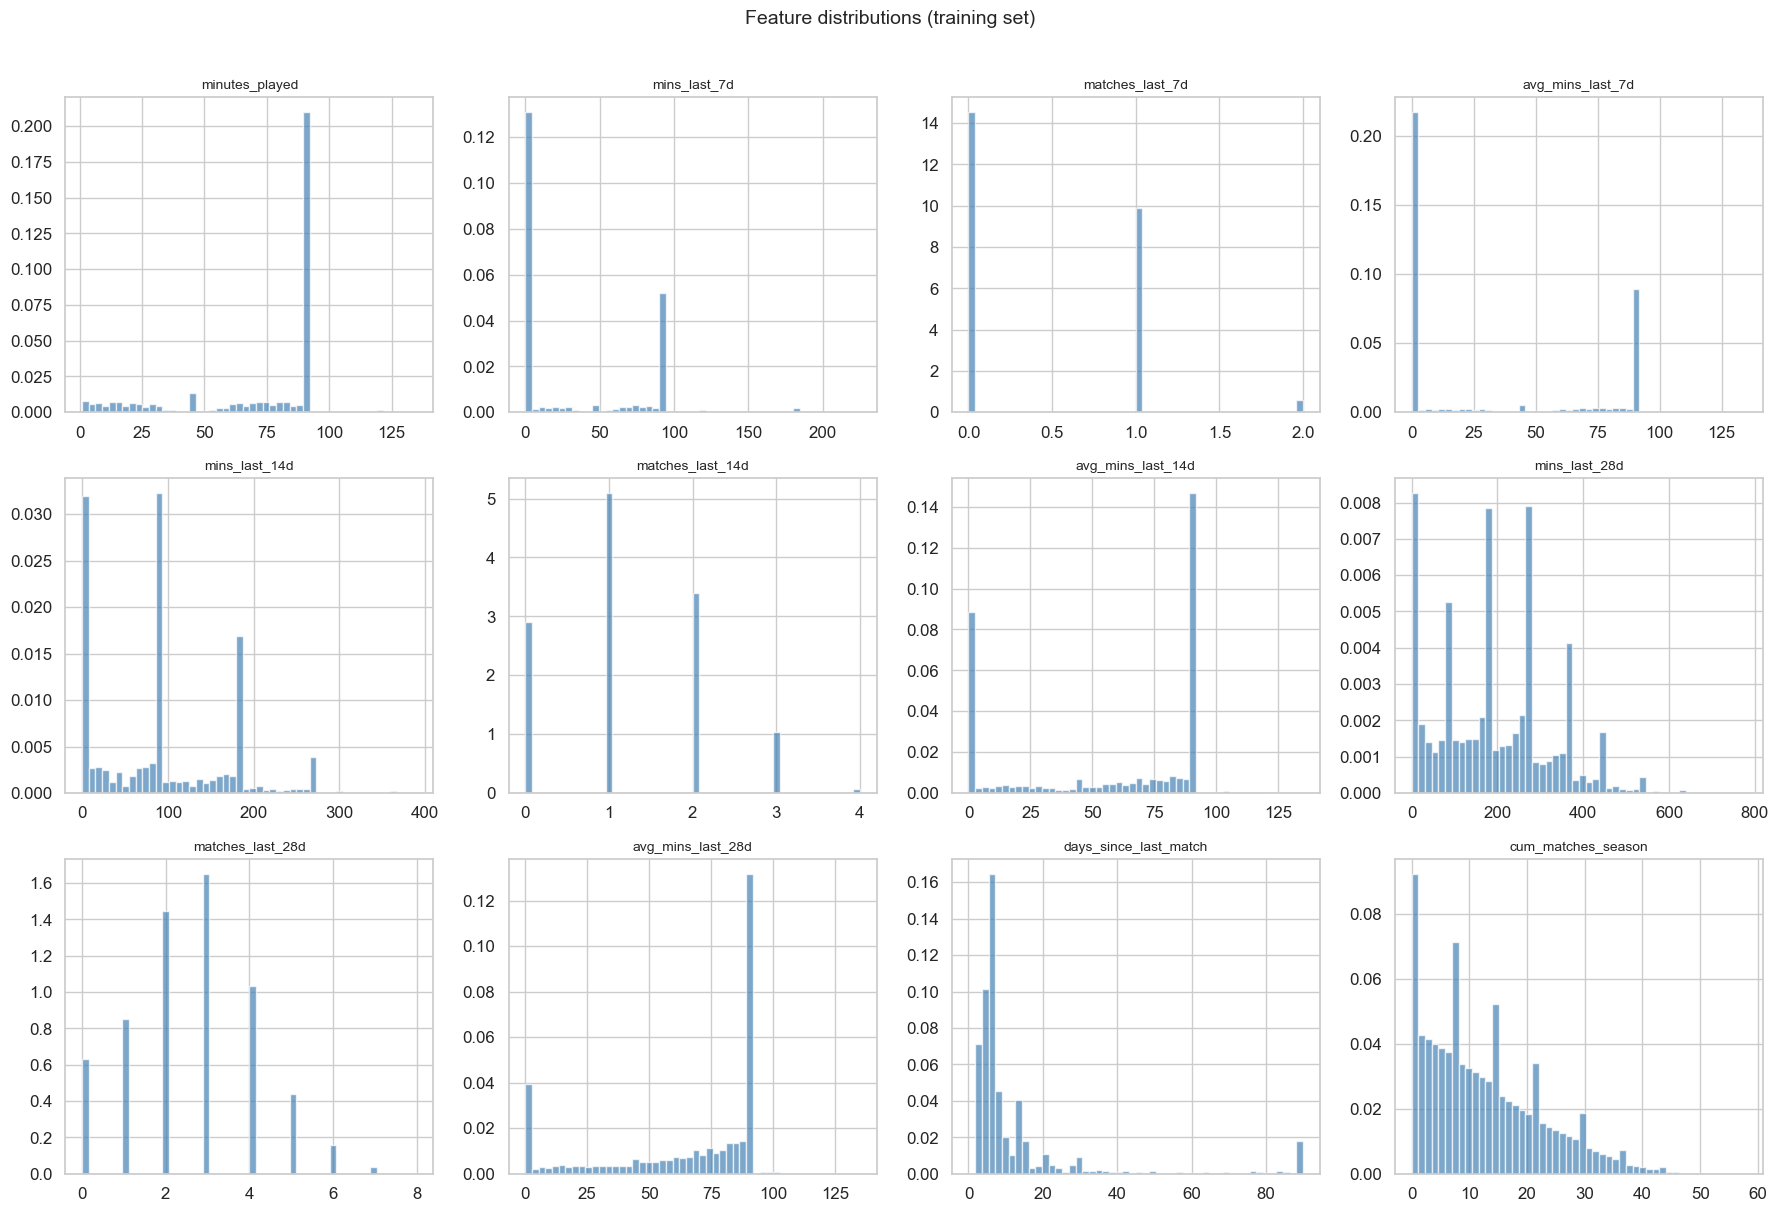

=== Feature correlations with injury_14d ===
days_since_last_injury      -0.046078
height_in_cm                -0.009888
minutes_played              -0.008998
position_enc                -0.008303
is_domestic_league          -0.007833
days_since_last_match       -0.006872
foot_enc                     0.002559
avg_mins_last_14d            0.004350
avg_mins_last_28d            0.004763
mins_last_28d                0.009905
mins_last_14d                0.012183
cum_matches_season           0.012806
matches_last_28d             0.013202
matches_last_14d             0.014574
avg_mins_last_7d             0.015053
mins_last_7d                 0.015827
matches_last_7d              0.017403
age_at_match                 0.032066
recent_return_30d            0.050655
all_injuries_career          0.065149
prior_target_injuries        0.080374
target_injuries_last_365d    0.091534


In [13]:
# ── B7. Feature distributions (quick sanity check) ──────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS[:12]):
    ax = axes[i]
    train[col].hist(bins=50, ax=ax, color="steelblue", alpha=0.7, density=True)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("")

plt.suptitle("Feature distributions (training set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Correlation of features with target
corr_with_target = train[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
print("=== Feature correlations with injury_14d ===")
print(corr_with_target.to_string())

---
# C. Modeling

**Strategy:**
1. **Logistic Regression** (baseline) — interpretable, fast, establishes a floor
2. **Random Forest** — non-linear, handles interactions, robust to feature scale
3. **LightGBM** — gradient boosting, strong on tabular data, handles imbalance natively

All models use `class_weight="balanced"` or equivalent to handle the severe class imbalance (~2-3% prevalence). Hyperparameters are set conservatively — no heavy tuning on this prototype.

In [14]:
# ── C1. Model 1 — Logistic Regression (baseline) ────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    random_state=42,
)
lr.fit(X_train_sc, y_train)

# Validation performance
lr_val_proba = lr.predict_proba(X_val_sc)[:, 1]
lr_test_proba = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(f"  Val  ROC-AUC:  {roc_auc_score(y_val, lr_val_proba):.4f}")
print(f"  Val  AUPRC:    {average_precision_score(y_val, lr_val_proba):.4f}")
print(f"  Test ROC-AUC:  {roc_auc_score(y_test, lr_test_proba):.4f}")
print(f"  Test AUPRC:    {average_precision_score(y_test, lr_test_proba):.4f}")

# Coefficients
coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending=False)
print("\nTop coefficients:")
display(coef_df)

=== Logistic Regression (Baseline) ===
  Val  ROC-AUC:  0.6735
  Val  AUPRC:    0.0404
  Test ROC-AUC:  0.6648
  Test AUPRC:    0.0459

Top coefficients:


,feature,coefficient
16,all_injuries_career,0.239753
15,target_injuries_last_365d,0.229076
9,avg_mins_last_28d,0.170970
12,prior_target_injuries,0.119745
8,matches_last_28d,0.100343
4,mins_last_14d,0.095629
10,days_since_last_match,0.078459
14,recent_return_30d,0.063878
2,matches_last_7d,0.060421
17,age_at_match,0.057324


In [15]:
# ── C2. Model 2 — Random Forest ──────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_val_proba  = rf.predict_proba(X_val)[:, 1]
rf_test_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"  Val  ROC-AUC:  {roc_auc_score(y_val, rf_val_proba):.4f}")
print(f"  Val  AUPRC:    {average_precision_score(y_val, rf_val_proba):.4f}")
print(f"  Test ROC-AUC:  {roc_auc_score(y_test, rf_test_proba):.4f}")
print(f"  Test AUPRC:    {average_precision_score(y_test, rf_test_proba):.4f}")

=== Random Forest ===
  Val  ROC-AUC:  0.6867
  Val  AUPRC:    0.0446
  Test ROC-AUC:  0.6805
  Test AUPRC:    0.0525


In [16]:
# ── C3. Model 3 — LightGBM ───────────────────────────────────────────
# Compute scale_pos_weight for imbalance handling
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=50,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.log_evaluation(0)],
)

lgb_val_proba  = lgb_model.predict_proba(X_val)[:, 1]
lgb_test_proba = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"  Val  ROC-AUC:  {roc_auc_score(y_val, lgb_val_proba):.4f}")
print(f"  Val  AUPRC:    {average_precision_score(y_val, lgb_val_proba):.4f}")
print(f"  Test ROC-AUC:  {roc_auc_score(y_test, lgb_test_proba):.4f}")
print(f"  Test AUPRC:    {average_precision_score(y_test, lgb_test_proba):.4f}")

  File "C:\Users\storm\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\storm\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\storm\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\storm\anaconda3\Lib\subprocess.

=== LightGBM ===
  Val  ROC-AUC:  0.6728
  Val  AUPRC:    0.0431
  Test ROC-AUC:  0.6422
  Test AUPRC:    0.0468


---
# D. Evaluation

Metrics appropriate for rare-event binary classification:
- **ROC-AUC**: discrimination ability
- **AUPRC (PR-AUC)**: performance under class imbalance (compare to prevalence baseline)
- **Confusion matrix** at chosen threshold
- **Calibration curve**: are predicted probabilities trustworthy?
- **Feature importance**: what drives the model?
- **Threshold analysis**: trade-off between alert volume and recall

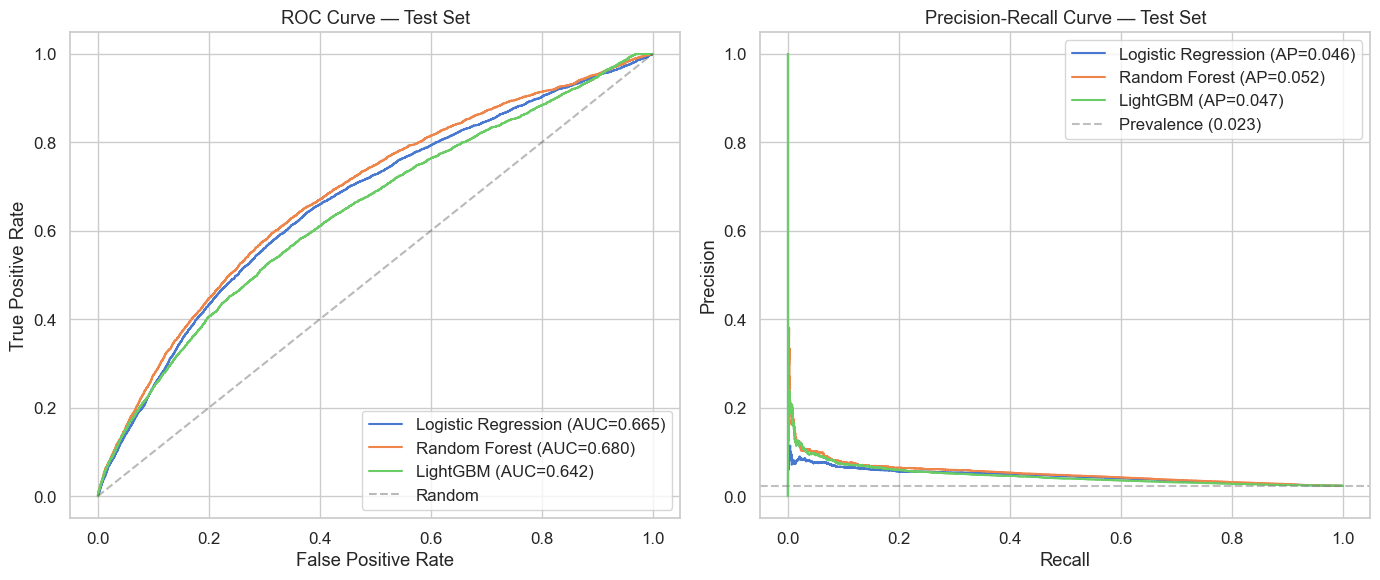

In [17]:
# ── D1. ROC & PR curves (test set) ──────────────────────────────────
models = {
    "Logistic Regression": lr_test_proba,
    "Random Forest": rf_test_proba,
    "LightGBM": lgb_test_proba,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
ax = axes[0]
for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")

# PR curves
ax = axes[1]
prevalence = y_test.mean()
for name, proba in models.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
ax.axhline(prevalence, color="gray", linestyle="--", alpha=0.5, label=f"Prevalence ({prevalence:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Test Set")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [18]:
# ── D2. Summary comparison table ─────────────────────────────────────
summary_rows = []
for name, proba in models.items():
    # Use threshold that maximizes F1 on validation set
    val_proba = {"Logistic Regression": lr_val_proba, 
                 "Random Forest": rf_val_proba,
                 "LightGBM": lgb_val_proba}[name]
    
    prec_v, rec_v, thresh_v = precision_recall_curve(y_val, val_proba)
    f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
    best_idx = np.argmax(f1_v)
    best_threshold = thresh_v[min(best_idx, len(thresh_v)-1)]
    
    y_pred = (proba >= best_threshold).astype(int)
    
    summary_rows.append({
        "Model": name,
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4),
        "AUPRC": round(average_precision_score(y_test, proba), 4),
        "Threshold": round(best_threshold, 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Alerts/day (est)": int(y_pred.sum() / max((test.date.max() - test.date.min()).days, 1) * 30),
    })

summary_df = pd.DataFrame(summary_rows)
print("=== Model Comparison — Test Set ===")
display(summary_df)

=== Model Comparison — Test Set ===


,Model,ROC-AUC,AUPRC,Threshold,Precision,Recall,F1,Accuracy,Alerts/day (est)
0,Logistic Regression,0.6648,0.0459,0.7809,0.0544,0.2711,0.0906,0.8741,1060
1,Random Forest,0.6805,0.0525,0.6791,0.0650,0.1886,0.0967,0.9184,617
2,LightGBM,0.6422,0.0468,0.7415,0.0673,0.1452,0.0920,0.9337,459


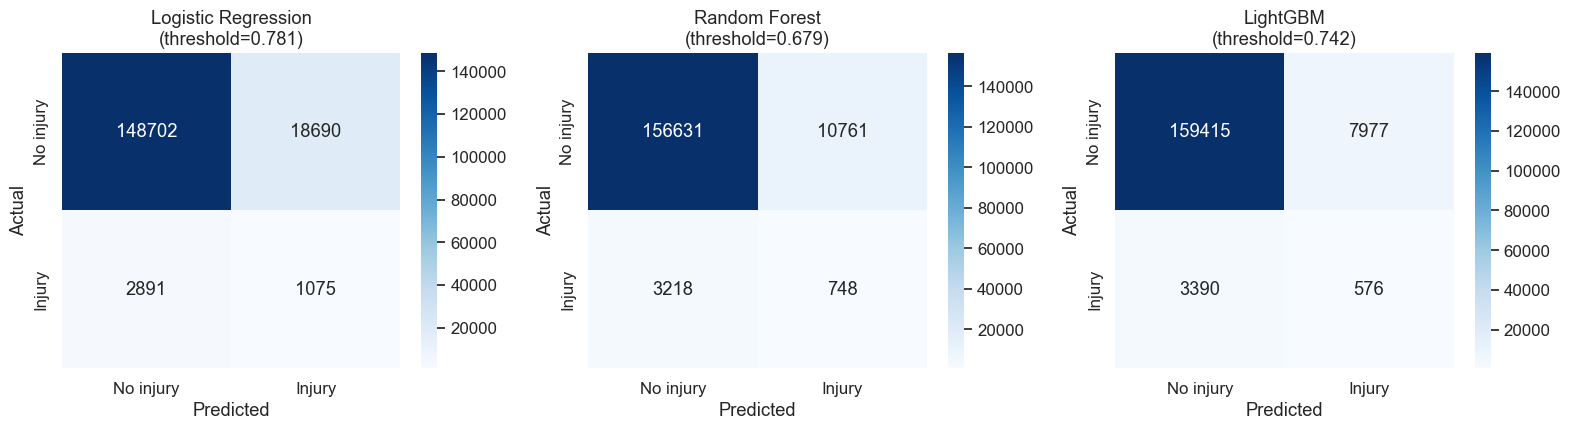

In [19]:
# ── D3. Confusion matrices ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, proba) in zip(axes, models.items()):
    val_proba = {"Logistic Regression": lr_val_proba,
                 "Random Forest": rf_val_proba,
                 "LightGBM": lgb_val_proba}[name]
    prec_v, rec_v, thresh_v = precision_recall_curve(y_val, val_proba)
    f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
    best_threshold = thresh_v[min(np.argmax(f1_v), len(thresh_v)-1)]
    
    y_pred = (proba >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No injury", "Injury"],
                yticklabels=["No injury", "Injury"])
    ax.set_title(f"{name}\n(threshold={best_threshold:.3f})")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

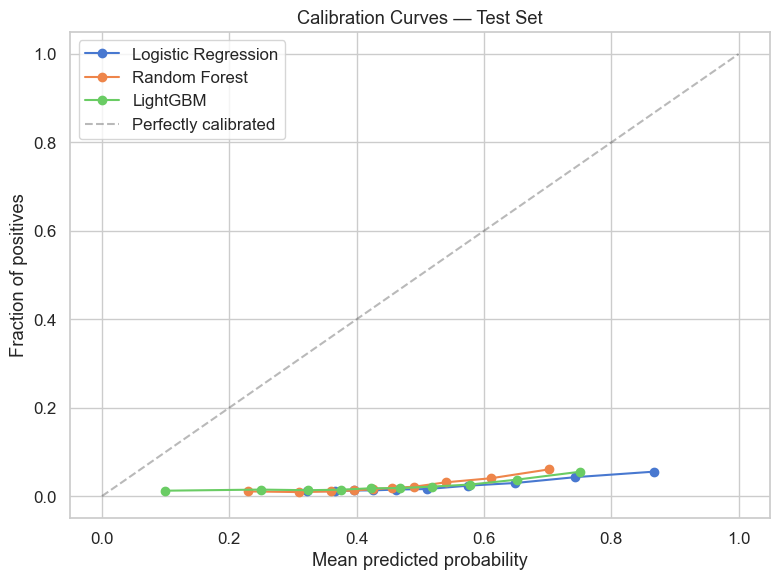

In [20]:
# ── D4. Calibration curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for name, proba in models.items():
    fraction_pos, mean_predicted = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_predicted, fraction_pos, marker="o", label=name)

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curves — Test Set")
ax.legend()
plt.tight_layout()
plt.show()

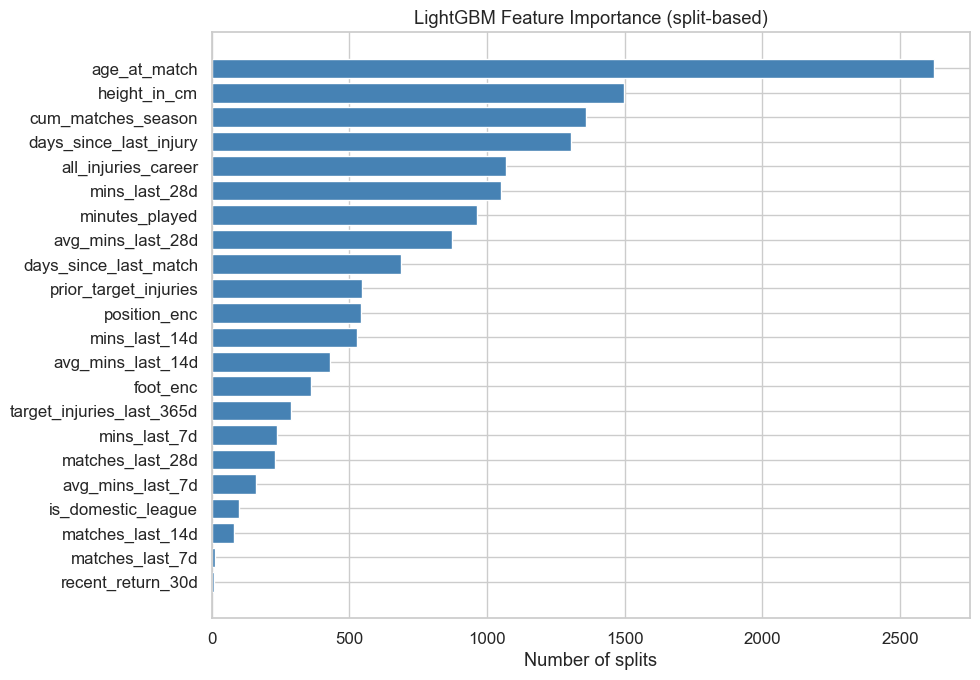

In [21]:
# ── D5. Feature importance (LightGBM) ────────────────────────────────
feat_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp["feature"], feat_imp["importance"], color="steelblue")
ax.set_title("LightGBM Feature Importance (split-based)")
ax.set_xlabel("Number of splits")
plt.tight_layout()
plt.show()

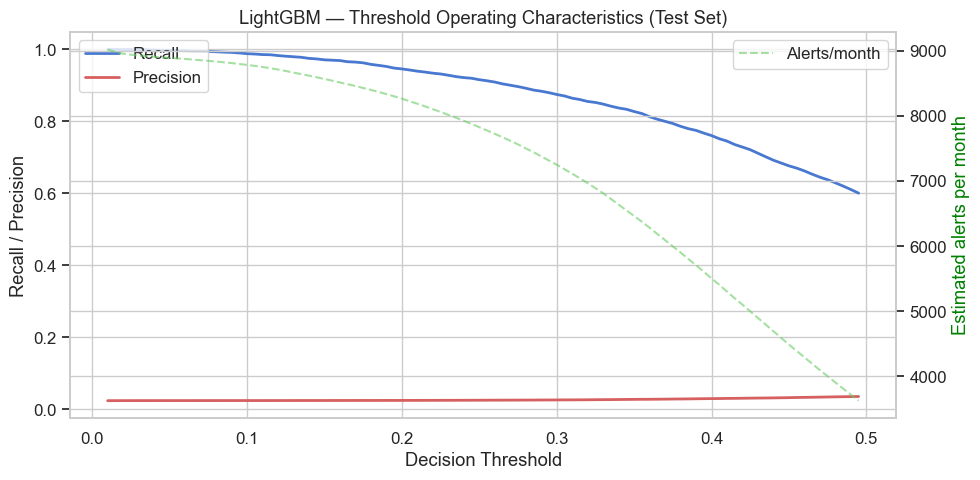

=== Selected operating points (LightGBM) ===
  t=0.030  →  recall=1.00  precision=0.024  alerts/month≈8927
  t=0.050  →  recall=1.00  precision=0.024  alerts/month≈8890
  t=0.100  →  recall=0.99  precision=0.024  alerts/month≈8782
  t=0.150  →  recall=0.97  precision=0.024  alerts/month≈8566
  t=0.200  →  recall=0.95  precision=0.024  alerts/month≈8263


In [22]:
# ── D6. Threshold analysis — recall vs alert volume ──────────────────
# For the best model (LightGBM), show how threshold affects operational metrics

thresholds = np.arange(0.01, 0.50, 0.005)
threshold_analysis = []

total_days = max((test.date.max() - test.date.min()).days, 1)

for t in thresholds:
    y_pred = (lgb_test_proba >= t).astype(int)
    tp = ((y_pred == 1) & (y_test == 1)).sum()
    fp = ((y_pred == 1) & (y_test == 0)).sum()
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    alerts_per_month = y_pred.sum() / total_days * 30
    
    threshold_analysis.append({
        "threshold": t, "precision": prec, "recall": rec,
        "alerts_per_month": alerts_per_month, "total_alerts": y_pred.sum()
    })

ta = pd.DataFrame(threshold_analysis)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ta.threshold, ta.recall, "b-", linewidth=2, label="Recall")
ax1.plot(ta.threshold, ta.precision, "r-", linewidth=2, label="Precision")
ax1.set_xlabel("Decision Threshold")
ax1.set_ylabel("Recall / Precision")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(ta.threshold, ta.alerts_per_month, "g--", alpha=0.6, label="Alerts/month")
ax2.set_ylabel("Estimated alerts per month", color="green")
ax2.legend(loc="upper right")

ax1.set_title("LightGBM — Threshold Operating Characteristics (Test Set)")
plt.tight_layout()
plt.show()

# Show a few operating points
print("=== Selected operating points (LightGBM) ===")
for t in [0.03, 0.05, 0.10, 0.15, 0.20]:
    row = ta.iloc[(ta.threshold - t).abs().argmin()]
    print(f"  t={row.threshold:.3f}  →  recall={row.recall:.2f}  precision={row.precision:.3f}  "
          f"alerts/month≈{row.alerts_per_month:.0f}")

---
# E. Conclusion — Business Relevance & Production Readiness

## Executive Summary

We built a **14-day forward injury prediction model** for non-contact lower-limb soft-tissue injuries in elite football, using publicly available Transfermarkt data. The pipeline joins **1.7M+ appearance records** with **143K injury episodes** across **15K+ players** (2012–2025), engineers 21 features from rolling workload, injury history, and player demographics, and evaluates three models under a strict temporal split.

## What the Data Supports

**Strengths:**
- Large-scale longitudinal match exposure data (13+ seasons, dense coverage)
- Structured injury labels with date ranges and body-part descriptions
- Sufficient target-injury prevalence (~2–3%) to train meaningful models
- Clean join between appearances and injuries on `player_id`

**Limitations (critical for honest assessment):**
- **No GPS/tracking data** in the modeling pipeline → workload is approximated by minutes played (a coarse proxy)
- **No wellness/subjective data** (RPE, sleep, soreness, mood) → strongest known predictors are absent
- **Injury labels are crowd-sourced** from Transfermarkt → noisy, possibly delayed, may miss minor injuries
- **Injury type classification is keyword-based** → cannot distinguish contact vs. non-contact with certainty
- **No within-match intensity data** → a 90-minute easy game and a 90-minute sprint-heavy game look identical

## Production Readiness Assessment

| Criterion | Status | Comment |
|-----------|--------|---------|
| Label quality | Moderate | Crowd-sourced, keyword-filtered; no clinical ground truth |
| Feature completeness | Weak | Missing GPS, wellness, training load — the strongest known predictors |
| Temporal stability | To verify | Model tested on 2024+ data; longer monitoring needed |
| Calibration | Likely poor | Predicted probabilities may not reflect true risk without wellness data |
| Leakage risk | Low | All features are strictly backward-looking; label looks forward only |
| Actionability | Limited | Without sub-position, training load, or wellness context, alerts lack specificity |
| Governance | Not addressed | Health-sensitive data requires explicit consent, access controls, and human review |

**Verdict: This model is NOT production-ready.** It is a defensible research baseline that demonstrates the pipeline and quantifies what public data alone can achieve. The key bottleneck is feature poverty (no physical load or wellness data), not modeling methodology.

## Most Important Next Steps

1. **Integrate GPS/tracking data** (e.g., SkillCorner, Catapult, STATSports) — high-speed running distance, accelerations, and session load are the strongest known injury predictors
2. **Add wellness/subjective data** (RPE, sleep quality, perceived fatigue) — improves both recall and calibration
3. **Improve injury labels** — use club medical records instead of Transfermarkt for ground truth
4. **Add training session exposure** — match-only data misses 60–80% of total training load
5. **Model recurrence separately** — a player returning from hamstring injury has fundamentally different risk
6. **Prospective validation** — deploy on a single team for one season before trusting predictions

## What Would Change the Verdict

If GPS tracking + wellness data were available for even 1–2 seasons of a single league, the model could likely achieve clinically meaningful discrimination (AUPRC > 0.15–0.20), which would support a **decision-support tool** (not autonomous decision-maker) for sports science staff.

---
*This analysis was produced as a research prototype. All model outputs require human expert review before any clinical or operational use. Injury data is health-sensitive and subject to data protection regulations.*